# LC25000 colon tissue classification

## Final reproducible project notebook

This notebook compares two approaches on the same **group-aware** partition of
the colon subset of LC25000:

1. a classical baseline using 96 RGB-histogram features and logistic regression;
2. a frozen ImageNet ResNet50 feature extractor with a binary classification head.

The published LC25000-clean grouping table keeps augmented sister images in one
partition. This reduces augmentation leakage, but it is **not** patient-level or
external clinical validation. The work is for research and education only and
must not be used for diagnosis or clinical decisions.


## 1. Environment and reproducibility

The seed, dataset identifier, requested partition fractions, and output directory
are declared once. All later sections consume these shared definitions.


In [1]:
import os
import shutil
import itertools
from glob import glob
from pathlib import Path
import json
import platform

In [2]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

import keras
import tensorflow as tf
from keras.models import Model
from keras.callbacks import EarlyStopping
from keras.utils import get_file

import kagglehub

In [3]:
SEED = 42
keras.utils.set_random_seed(SEED)
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15
DATASET_ID = "andrewmvd/lung-and-colon-cancer-histopathological-images"

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [4]:
OUTPUT_DIR = Path("/content/lc25000-final-outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BATCH_SIZE = 32
IMG_SIZE = 224

assert TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION == 1.0
print({
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
    "keras": keras.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
})


{'python': '3.12.13', 'tensorflow': '2.20.0', 'keras': '3.13.2', 'pandas': '2.2.2', 'scikit_learn': '1.6.1'}


## 2. Dataset acquisition and binary colon index

The Kaggle dataset is downloaded at runtime. Only benign colon tissue and colon
adenocarcinoma are indexed. Portable relative paths are retained for evidence.


In [5]:
dataset_root = Path(kagglehub.dataset_download(DATASET_ID))

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.


In [6]:
colon_directories = list(dataset_root.rglob("colon_image_sets"))

if len(colon_directories) != 1:
    raise RuntimeError(
        f"Expected exactly one colon_image_sets directory, found {colon_directories}"
    )

colon_root = colon_directories[0]
print("Dataset root:", dataset_root)
print("Colon root:", colon_root)

Dataset root: /kaggle/input/lung-and-colon-cancer-histopathological-images
Colon root: /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets


In [7]:
CLASS_MAPPING = {
    "colon_n": {"label": 0, "class_name": "benign"},
    "colon_aca": {"label": 1, "class_name": "adenocarcinoma"},
}
SUPPORTED_SUFFIXES = {".jpg", ".jpeg", ".png"}
records = []

for folder_name, class_info in CLASS_MAPPING.items():
    class_directory = colon_root / folder_name
    if not class_directory.is_dir():
        raise FileNotFoundError(f"Missing expected class directory: {class_directory}")

    image_paths = sorted(
        path for path in class_directory.iterdir()
        if path.is_file() and path.suffix.lower() in SUPPORTED_SUFFIXES
    )
    for image_path in image_paths:
        records.append({
            "relative_path": image_path.relative_to(colon_root).as_posix(),
            "filepath": str(image_path),
            "label": class_info["label"],
            "class_name": class_info["class_name"],
        })

image_index = pd.DataFrame.from_records(records).sort_values(
    ["label", "relative_path"]
).reset_index(drop=True)

expected_counts = {"benign": 5000, "adenocarcinoma": 5000}
actual_counts = image_index["class_name"].value_counts().to_dict()
assert actual_counts == expected_counts, (actual_counts, expected_counts)
assert len(image_index) == 10_000
assert image_index["relative_path"].is_unique
display(image_index.head())
display(image_index["class_name"].value_counts().sort_index())


,relative_path,filepath,label,class_name
0,colon_n/colonn1.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
1,colon_n/colonn10.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
2,colon_n/colonn100.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
3,colon_n/colonn1000.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
4,colon_n/colonn1001.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign


,count
class_name,
adenocarcinoma,5000
benign,5000


## 3. Official LC25000-clean groups

The public grouping table assigns augmented versions of the same source tile to
one `group_id`. Every local colon image must match exactly one published row.


In [8]:
GROUPS_URL = (
    "https://raw.githubusercontent.com/GeorgeBatch/"
    "LC25000-clean/main/kaggle/lc25000_image_groups.csv"
)
EXPECTED_GROUP_COLUMNS = {
    "stem",
    "filename",
    "label",
    "tissue",
    "local_cluster_label",
    "group_id",
}

image_groups = pd.read_csv(GROUPS_URL)

assert len(image_groups) == 25_000, len(image_groups)
assert set(image_groups.columns) == EXPECTED_GROUP_COLUMNS, image_groups.columns.tolist()
assert image_groups["stem"].is_unique
assert image_groups["group_id"].notna().all()

print("Grouping table shape:", image_groups.shape)
print("Columns:", image_groups.columns.tolist())
print("Unique groups:", image_groups["group_id"].nunique())
display(image_groups["tissue"].value_counts().sort_index())
display(image_groups["label"].value_counts().sort_index())
display(image_groups.head())


Grouping table shape: (25000, 6)
Columns: ['stem', 'filename', 'label', 'tissue', 'local_cluster_label', 'group_id']
Unique groups: 1246


,count
tissue,
colon,10000
lung,15000


,count
label,
colon_aca,5000
colon_n,5000
lung_aca,5000
lung_n,5000
lung_scc,5000


,stem,filename,label,tissue,local_cluster_label,group_id
0,colonca1021,colonca1021.jpeg,colon_aca,colon,0,0
1,colonca1078,colonca1078.jpeg,colon_aca,colon,0,0
2,colonca1139,colonca1139.jpeg,colon_aca,colon,0,0
3,colonca1256,colonca1256.jpeg,colon_aca,colon,0,0
4,colonca1496,colonca1496.jpeg,colon_aca,colon,0,0


In [9]:
OFFICIAL_TO_CLASS_NAME = {
    "colon_n": "benign",
    "colon_aca": "adenocarcinoma",
}

colon_groups = image_groups.loc[
    image_groups["tissue"].eq("colon"),
    ["stem", "filename", "label", "local_cluster_label", "group_id"],
].rename(columns={"label": "official_label"})

assert len(colon_groups) == 10_000
assert colon_groups["stem"].is_unique

grouped_image_index = image_index.copy()
grouped_image_index["stem"] = grouped_image_index["relative_path"].map(
    lambda value: Path(value).stem
)
grouped_image_index = grouped_image_index.merge(
    colon_groups,
    on="stem",
    how="left",
    validate="one_to_one",
    indicator=True,
)

assert len(grouped_image_index) == 10_000
assert grouped_image_index["relative_path"].is_unique
assert grouped_image_index["_merge"].eq("both").all(), (
    grouped_image_index["_merge"].value_counts().to_dict()
)
assert grouped_image_index["group_id"].notna().all()
assert grouped_image_index["official_label"].map(OFFICIAL_TO_CLASS_NAME).equals(
    grouped_image_index["class_name"]
)
grouped_image_index = grouped_image_index.drop(columns="_merge")

print("Matched colon images:", len(grouped_image_index))
print("Unique colon groups:", grouped_image_index["group_id"].nunique())
display(grouped_image_index.groupby("class_name")["group_id"].nunique())
display(grouped_image_index.groupby("class_name")["group_id"].size())
display(grouped_image_index.head())


Matched colon images: 10000
Unique colon groups: 506


,group_id
class_name,
adenocarcinoma,249
benign,257


,group_id
class_name,
adenocarcinoma,5000
benign,5000


,relative_path,filepath,label,class_name,stem,filename,official_label,local_cluster_label,group_id
0,colon_n/colonn1.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign,colonn1,colonn1.jpeg,colon_n,25,274
1,colon_n/colonn10.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign,colonn10,colonn10.jpeg,colon_n,12,261
2,colon_n/colonn100.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign,colonn100,colonn100.jpeg,colon_n,157,406
3,colon_n/colonn1000.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign,colonn1000,colonn1000.jpeg,colon_n,65,314
4,colon_n/colonn1001.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign,colonn1001,colonn1001.jpeg,colon_n,213,462


## 4. Group-aware train, validation, and test split

Each class is split independently, but complete groups—not individual images—are
assigned to train, validation, or test. Different group sizes make the final image
fractions approximate rather than exactly 70/15/15.


In [10]:
from sklearn.model_selection import GroupShuffleSplit

def split_complete_groups(class_frame, seed):
    """Return approximate 70/15/15 partitions without breaking a group."""
    train_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=VALIDATION_FRACTION + TEST_FRACTION,
        random_state=seed,
    )
    train_indices, temporary_indices = next(
        train_splitter.split(class_frame, groups=class_frame["group_id"])
    )
    train_frame = class_frame.iloc[train_indices]
    temporary_frame = class_frame.iloc[temporary_indices]

    validation_test_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION),
        random_state=seed + 1,
    )
    validation_indices, test_indices = next(
        validation_test_splitter.split(
            temporary_frame,
            groups=temporary_frame["group_id"],
        )
    )
    return {
        "train": train_frame,
        "validation": temporary_frame.iloc[validation_indices],
        "test": temporary_frame.iloc[test_indices],
    }

class_partitions = {
    class_name: split_complete_groups(class_frame, SEED)
    for class_name, class_frame in grouped_image_index.groupby("class_name", sort=True)
}
partitions = {
    split_name: pd.concat(
        [class_splits[split_name] for class_splits in class_partitions.values()],
        ignore_index=True,
    ).sort_values(["label", "relative_path"]).reset_index(drop=True)
    for split_name in ("train", "validation", "test")
}

partition_summary = pd.DataFrame([
    {
        "split": split_name,
        "class_name": class_name,
        "images": len(class_frame),
        "groups": class_frame["group_id"].nunique(),
    }
    for split_name, split_frame in partitions.items()
    for class_name, class_frame in split_frame.groupby("class_name", sort=True)
])
display(partition_summary)
display(partition_summary.groupby("split")[["images", "groups"]].sum())


,split,class_name,images,groups
0,train,adenocarcinoma,3516,174
1,train,benign,3567,179
2,validation,adenocarcinoma,730,37
3,validation,benign,736,39
4,test,adenocarcinoma,754,38
5,test,benign,697,39


,images,groups
split,,
test,1451,77
train,7083,353
validation,1466,76


In [11]:
assigned_frames = []
for split_name, frame in partitions.items():
    assigned = frame.copy()
    assigned.insert(0, "split", split_name)
    assigned_frames.append(assigned)

assigned_images = pd.concat(assigned_frames, ignore_index=True)

assert len(assigned_images) == len(grouped_image_index) == 10_000
assert assigned_images["relative_path"].is_unique
assert set(assigned_images["relative_path"]) == set(grouped_image_index["relative_path"])
assert assigned_images["filepath"].map(lambda value: Path(value).is_file()).all()
assert assigned_images["group_id"].nunique() == 506
assert assigned_images.groupby("group_id")["split"].nunique().eq(1).all()
assert assigned_images.groupby("group_id")["class_name"].nunique().eq(1).all()

group_sets = {
    split_name: set(frame["group_id"])
    for split_name, frame in partitions.items()
}
assert group_sets["train"].isdisjoint(group_sets["validation"])
assert group_sets["train"].isdisjoint(group_sets["test"])
assert group_sets["validation"].isdisjoint(group_sets["test"])
assert set.union(*group_sets.values()) == set(grouped_image_index["group_id"])

actual_fractions = {
    split_name: len(frame) / len(grouped_image_index)
    for split_name, frame in partitions.items()
}
print("Group-aware split integrity checks passed.")
print("Assigned images:", len(assigned_images))
print("Assigned groups:", assigned_images["group_id"].nunique())
print("Group overlap: 0")
print("Actual image fractions:", actual_fractions)


Group-aware split integrity checks passed.
Assigned images: 10000
Assigned groups: 506
Group overlap: 0
Actual image fractions: {'train': 0.7083, 'validation': 0.1466, 'test': 0.1451}


In [12]:
GROUP_SPLIT_MANIFEST_PATH = OUTPUT_DIR / "group_split_manifest.csv"
GROUP_SPLIT_METADATA_PATH = OUTPUT_DIR / "group_split_metadata.json"

train_df = partitions["train"]
validation_df = partitions["validation"]
test_df = partitions["test"]

group_split_manifest = assigned_images[[
    "split", "relative_path", "label", "class_name", "stem",
    "official_label", "local_cluster_label", "group_id",
]].sort_values(["split", "label", "relative_path"]).reset_index(drop=True)

group_split_manifest.to_csv(GROUP_SPLIT_MANIFEST_PATH, index=False)
group_split_metadata = {
    "schema_version": 1,
    "dataset_id": DATASET_ID,
    "groups_source_url": GROUPS_URL,
    "split_method": "two-stage GroupShuffleSplit within each class",
    "seed": SEED,
    "requested_fractions": {
        "train": TRAIN_FRACTION,
        "validation": VALIDATION_FRACTION,
        "test": TEST_FRACTION,
    },
    "actual_image_fractions": actual_fractions,
    "image_counts": {name: len(frame) for name, frame in partitions.items()},
    "group_counts": {
        name: int(frame["group_id"].nunique()) for name, frame in partitions.items()
    },
    "total_images": int(len(group_split_manifest)),
    "total_groups": int(group_split_manifest["group_id"].nunique()),
    "group_overlap": 0,
    "class_mapping": {"benign": 0, "adenocarcinoma": 1},
    "limitation": "Group-aware tile evaluation is not patient-level validation.",
}
GROUP_SPLIT_METADATA_PATH.write_text(
    json.dumps(group_split_metadata, indent=2), encoding="utf-8"
)
print("Saved:", GROUP_SPLIT_MANIFEST_PATH)
print("Saved:", GROUP_SPLIT_METADATA_PATH)


Saved: /content/lc25000-final-outputs/group_split_manifest.csv
Saved: /content/lc25000-final-outputs/group_split_metadata.json


## 5. Color-only logistic-regression baseline

Each image is reduced to 32 histogram bins for each RGB channel (96 values). A
standardized logistic regression then estimates adenocarcinoma probability. This
tests how much of the task can be solved from global color without spatial texture
or morphology.


### Experiment 4 contribution: color signature

The function below was contributed by **Dhamar Quishpe Rivera** in Experiment 4.
It crops the image center, computes 32 histogram bins for each RGB channel, and
L2-normalizes the resulting 96-value signature. The same contribution is used for
both the logistic-regression baseline and the random-split similarity audit.


Imagenes de prueba con una hermana casi identica en entrenamiento:
  similitud >= 0.99: 76.9%
  similitud >= 0.995: 38.5%
  similitud >= 0.999: 0.1%


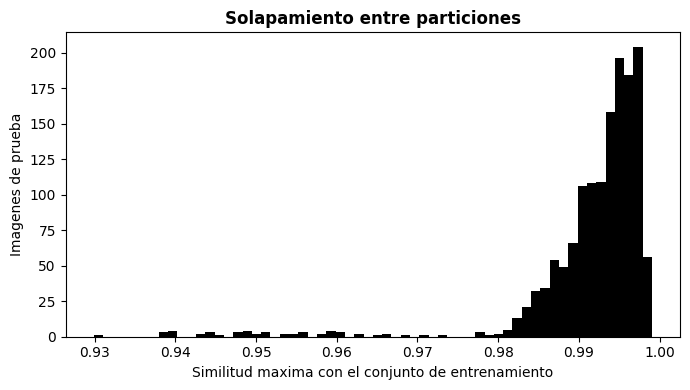

In [13]:
from PIL import Image

def firma_de_color(ruta, bins=32):
    """Descriptor invariante a rotacion y volteo.

    Las imagenes hermanas del dataset son rotaciones y volteos de un mismo corte,
    operaciones que no alteran la distribucion de valores de sus pixeles. El
    histograma de color del centro de la imagen es por tanto casi identico entre
    hermanas y distinto entre cortes de origen diferentes.
    """
    with Image.open(ruta) as archivo:
        archivo.draft("RGB", (256, 256))
        imagen = archivo.convert("RGB").resize((128, 128))
    centro = np.asarray(imagen, dtype=np.uint8)[19:109, 19:109]
    histograma = np.concatenate([
        np.histogram(centro[..., canal], bins=bins, range=(0, 256))[0]
        for canal in range(3)
    ]).astype("float32")
    return histograma / np.linalg.norm(histograma)


firmas = np.stack([firma_de_color(ruta) for ruta in image_index["filepath"]])
posicion = {ruta: i for i, ruta in enumerate(image_index["relative_path"])}
idx_train = np.array([posicion[r] for r in train_df["relative_path"]])
idx_test = np.array([posicion[r] for r in test_df["relative_path"]])

similitud_maxima = (firmas[idx_test] @ firmas[idx_train].T).max(axis=1)

print("Imagenes de prueba con una hermana casi identica en entrenamiento:")
for umbral in (0.99, 0.995, 0.999):
    print(f"  similitud >= {umbral}: {(similitud_maxima >= umbral).mean():.1%}")

plt.figure(figsize=(7, 4))
plt.hist(similitud_maxima, bins=60, color="black")
plt.xlabel("Similitud maxima con el conjunto de entrenamiento")
plt.ylabel("Imagenes de prueba")
plt.title("Solapamiento entre particiones", weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "solapamiento_particiones.png", dpi=160, bbox_inches="tight")
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

HISTOGRAM_METRICS_PATH = OUTPUT_DIR / "color_histogram_baseline_metrics.json"
HISTOGRAM_PREDICTIONS_PATH = OUTPUT_DIR / "color_histogram_test_predictions.csv"

firmas = np.empty((len(grouped_image_index), 96), dtype=np.float32)
for position, filepath in enumerate(grouped_image_index["filepath"]):
    firmas[position] = firma_de_color(filepath)
    if (position + 1) % 1000 == 0:
        print(f"Calculated {position + 1:,}/10,000 color signatures")

assert firmas.shape == (10_000, 96)
assert np.isfinite(firmas).all()
signature_position = {
    relative_path: position
    for position, relative_path in enumerate(grouped_image_index["relative_path"])
}

def firmas_de(frame):
    # Select color signatures in the exact row order of a partition.
    positions = [signature_position[path] for path in frame["relative_path"]]
    return firmas[positions]

histogram_baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=SEED),
)
histogram_baseline.fit(firmas_de(train_df), train_df["label"])
histogram_predictions = histogram_baseline.predict(firmas_de(test_df))
histogram_probabilities = histogram_baseline.predict_proba(firmas_de(test_df))[:, 1]
histogram_accuracy = accuracy_score(test_df["label"], histogram_predictions)
histogram_report = classification_report(
    test_df["label"],
    histogram_predictions,
    target_names=["benign", "adenocarcinoma"],
    output_dict=True,
    zero_division=0,
)
histogram_error_mask = test_df["label"].to_numpy() != histogram_predictions
histogram_metrics = {
    "experiment_id": "final-color-histogram-baseline",
    "features": "32 L2-normalized center-crop histogram bins per RGB channel",
    "feature_count": 96,
    "classifier": "StandardScaler + LogisticRegression",
    "split_manifest": "group_split_manifest.csv",
    "test_accuracy": float(histogram_accuracy),
    "test_samples": int(len(test_df)),
    "test_groups": int(test_df["group_id"].nunique()),
    "misclassified_images": int(histogram_error_mask.sum()),
    "groups_with_any_error": int(
        test_df.loc[histogram_error_mask, "group_id"].nunique()
    ),
    "limitation": (
        "A high score shows that global color is predictive in this internal dataset; "
        "it is not patient-level or external clinical validation."
    ),
}
HISTOGRAM_METRICS_PATH.write_text(
    json.dumps({**histogram_metrics, "classification_report": histogram_report}, indent=2),
    encoding="utf-8",
)
histogram_prediction_evidence = test_df[[
    "relative_path", "class_name", "label", "group_id", "local_cluster_label"
]].copy()
histogram_prediction_evidence["adenocarcinoma_probability"] = histogram_probabilities
histogram_prediction_evidence["predicted_label"] = histogram_predictions
histogram_prediction_evidence.to_csv(HISTOGRAM_PREDICTIONS_PATH, index=False)

print(f"RGB-histogram test accuracy: {histogram_accuracy:.4f}")
print(classification_report(
    test_df["label"],
    histogram_predictions,
    target_names=["benign", "adenocarcinoma"],
    digits=4,
    zero_division=0,
))
print("Saved:", HISTOGRAM_METRICS_PATH)
print("Saved:", HISTOGRAM_PREDICTIONS_PATH)


Calculated 1,000/10,000 color signatures
Calculated 2,000/10,000 color signatures
Calculated 3,000/10,000 color signatures
Calculated 4,000/10,000 color signatures
Calculated 5,000/10,000 color signatures
Calculated 6,000/10,000 color signatures
Calculated 7,000/10,000 color signatures
Calculated 8,000/10,000 color signatures
Calculated 9,000/10,000 color signatures
Calculated 10,000/10,000 color signatures
RGB-histogram test accuracy: 0.9118
                precision    recall  f1-score   support

        benign     0.8552    0.9828    0.9146       697
adenocarcinoma     0.9815    0.8462    0.9088       754

      accuracy                         0.9118      1451
     macro avg     0.9184    0.9145    0.9117      1451
  weighted avg     0.9208    0.9118    0.9116      1451

Saved: /content/lc25000-final-outputs/color_histogram_baseline_metrics.json
Saved: /content/lc25000-final-outputs/color_histogram_test_predictions.csv


## 6. Diagnostic audit of the original random split

For comparison with the early experiments, a deterministic random image split is
created only for this audit. Cosine similarity between color signatures measures
how often a random-split test image has an extremely similar training image. This
diagnostic does not replace the official group IDs and is not used for final model
evaluation.


In [15]:
from sklearn.model_selection import train_test_split

random_train_df, random_temporary_df = train_test_split(
    grouped_image_index,
    test_size=VALIDATION_FRACTION + TEST_FRACTION,
    stratify=grouped_image_index["label"],
    random_state=SEED,
)
random_validation_df, random_test_df = train_test_split(
    random_temporary_df,
    test_size=TEST_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION),
    stratify=random_temporary_df["label"],
    random_state=SEED,
)

normalized_signatures = firmas

def normalized_signatures_for(frame):
    positions = [signature_position[path] for path in frame["relative_path"]]
    return normalized_signatures[positions]

random_similarity = (
    normalized_signatures_for(random_test_df)
    @ normalized_signatures_for(random_train_df).T
)
random_max_similarity = random_similarity.max(axis=1)
leakage_audit = {
    f"fraction_with_training_neighbor_at_{threshold}": float(
        np.mean(random_max_similarity >= threshold)
    )
    for threshold in (0.99, 0.995, 0.999)
}
leakage_audit.update({
    "random_train_images": int(len(random_train_df)),
    "random_test_images": int(len(random_test_df)),
    "median_max_similarity": float(np.median(random_max_similarity)),
    "interpretation": (
        "Histogram similarity is a diagnostic proxy; official group IDs define "
        "the authoritative group-aware split."
    ),
})
(OUTPUT_DIR / "random_split_similarity_audit.json").write_text(
    json.dumps(leakage_audit, indent=2), encoding="utf-8"
)
print(json.dumps(leakage_audit, indent=2))


{
  "fraction_with_training_neighbor_at_0.99": 1.0,
  "fraction_with_training_neighbor_at_0.995": 0.9933333333333333,
  "fraction_with_training_neighbor_at_0.999": 0.8006666666666666,
  "random_train_images": 7000,
  "random_test_images": 1500,
  "median_max_similarity": 0.9994341135025024,
  "interpretation": "Histogram similarity is a diagnostic proxy; official group IDs define the authoritative group-aware split."
}


## 7. Custom ResNet50 preprocessing and image generators

ImageNet ResNet50 weights expect Caffe-style preprocessing: RGB is reordered to
BGR and the ImageNet mean is subtracted from each channel. The implementation is
written explicitly and verified with a known red-pixel result. No
`keras.applications` preprocessing function is called. Only the training generator
applies augmentation.


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32
IMG_SIZE = 224

# Medias por canal del conjunto ImageNet, en orden BGR.
IMAGENET_BGR_MEANS = np.array([103.939, 116.779, 123.68], dtype="float32")


def preprocess_resnet50(image):
    """Replica el preprocesamiento con el que se entrenaron los pesos de ResNet50.

    Los pesos publicados provienen de un entrenamiento en Caffe, donde la entrada
    se ordena en BGR y se centra restando la media de cada canal, sin reescalar a
    [0, 1] ni a [-1, 1]. Aplicar una normalizacion distinta no produce error en
    ejecucion, pero desplaza la entrada respecto a la distribucion que vieron los
    filtros durante el preentrenamiento y degrada las representaciones extraidas.
    """
    image = np.asarray(image, dtype="float32")
    image = image[..., ::-1]                # RGB -> BGR
    return image - IMAGENET_BGR_MEANS       # centrado por canal


train_gen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_resnet50,
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="reflect"
)

eval_gen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_resnet50
)

# Verificacion: un pixel rojo puro (255, 0, 0) debe quedar como
# (0 - 103.939, 0 - 116.779, 255 - 123.68) al reordenarse a BGR.
_probe = preprocess_resnet50(np.array([[[255.0, 0.0, 0.0]]], dtype="float32"))
assert np.allclose(_probe[0, 0], [-103.939, -116.779, 131.32], atol=1e-3), _probe
assert _probe.dtype == np.float32
print("Normalizacion propia verificada:", _probe[0, 0])

Normalizacion propia verificada: [-103.939 -116.779  131.32 ]


In [17]:
# Continue from the verified approximate 70/15/15 group-aware split above.
# String labels make the generator's class mapping explicit.
train_df = partitions["train"]
validation_df = partitions["validation"]
test_df = partitions["test"]

generator_arguments = {
    "x_col": "filepath",
    "y_col": "class_name",
    "target_size": (IMG_SIZE, IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "class_mode": "binary",
    "classes": ["benign", "adenocarcinoma"],
}

train_resnet = train_gen_resnet.flow_from_dataframe(
    train_df, shuffle=True, seed=SEED, **generator_arguments
)
validation_resnet = eval_gen_resnet.flow_from_dataframe(
    validation_df, shuffle=False, **generator_arguments
)
test_resnet = eval_gen_resnet.flow_from_dataframe(
    test_df, shuffle=False, **generator_arguments
)

expected_class_indices = {"benign": 0, "adenocarcinoma": 1}
assert train_resnet.class_indices == expected_class_indices
assert validation_resnet.class_indices == expected_class_indices
assert test_resnet.class_indices == expected_class_indices
assert train_resnet.samples == len(train_df) == 7083
assert validation_resnet.samples == len(validation_df) == 1466
assert test_resnet.samples == len(test_df) == 1451

batch_images, batch_labels = next(iter(train_resnet))
assert batch_images.shape[1:] == (IMG_SIZE, IMG_SIZE, 3)
assert set(np.unique(batch_labels)).issubset({0.0, 1.0})
train_resnet.reset()
print("Generator checks passed.")
print("Class indices:", train_resnet.class_indices)
print("Batch shapes:", batch_images.shape, batch_labels.shape)

batch_signature = (
    tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(None,), dtype=tf.float32),
)

def as_tf_dataset(iterator):
    """Wrap a legacy image iterator in the Keras 3-supported tf.data boundary."""
    return tf.data.Dataset.from_generator(
        lambda: iter(iterator), output_signature=batch_signature
    )

train_dataset = as_tf_dataset(train_resnet)
validation_dataset = as_tf_dataset(validation_resnet)
test_dataset = as_tf_dataset(test_resnet)
dataset_images, dataset_labels = next(iter(train_dataset))
assert dataset_images.shape[1:] == (IMG_SIZE, IMG_SIZE, 3)
assert dataset_labels.shape[0] == dataset_images.shape[0]
train_resnet.reset()
print("tf.data adapter check passed.")

Found 7083 validated image filenames belonging to 2 classes.
Found 1466 validated image filenames belonging to 2 classes.
Found 1451 validated image filenames belonging to 2 classes.
Generator checks passed.
Class indices: {'benign': 0, 'adenocarcinoma': 1}
Batch shapes: (32, 224, 224, 3) (32,)
tf.data adapter check passed.


## Teaching annex: our first residual mini-blocks

These small `id_block` and `conv_block` implementations were created manually to
teach the residual connection idea. They are intentionally preserved and are not
used to train the final classifier because their topology is not compatible with
the published ImageNet ResNet50 weights.


In [18]:
# No se usa en el modelo entrenado: es incompatible con los pesos de ImageNet.
# Ver la justificacion en el anexo, encima de esta seccion.

def id_block(spatial_size, depth):
  """Bottleneck ID block

  Args:
    spatial_size:
    depth: depth of the bottleneck

  Returns:
    A model that can run block
  """
  if depth % 4 !=0:
    raise ValueError('Filters size must be divisible by 4')

  inputs = keras.layers.Input(shape=(*spatial_size, depth))
  # ID block S(x) = x
  shortcut = inputs


  x = keras.layers.Conv2D(filters=(depth//4), kernel_size=(1,1), padding='same', use_bias=False)(inputs)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=(depth//4), kernel_size=(3,3), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=depth, kernel_size=(1,1), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Add()([shortcut, x])
  outputs = keras.layers.Activation('relu')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

In [19]:
# No se usa en el modelo entrenado: es incompatible con los pesos de ImageNet.
# Ver la justificacion en el anexo, encima de esta seccion.

def conv_block(spatial_size, depth):
  """Bottleneck convolutional block

  Args:
    spatial_size:
    depth: depth of the bottleneck

  Returns:
    A model that can run block
  """
  if depth % 4 !=0:
    raise ValueError('Filters size must be divisible by 4')

  inputs = keras.layers.Input(shape=(*spatial_size, depth))
  # ID block S(x) = F(x)
  shortcut = keras.layers.Conv2D(filters=(depth*2), kernel_size=(1,1), padding='same', strides=(2,2))(inputs)

  x = keras.layers.Conv2D(filters=(depth//2), kernel_size=(1,1), padding='same', use_bias=False)(inputs)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)

  x = keras.layers.Conv2D(filters=(depth//2), kernel_size=(3,3), padding='same', strides=(2,2), use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=(depth*2), kernel_size=(1,1), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Add()([shortcut, x])
  outputs = keras.layers.Activation('relu')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

## 8. Explicit ResNet50 implementation and training protocol

The ResNet50 topology is defined below using Keras layers rather than instantiated
through `keras.applications`. Compatible ImageNet no-top weights are downloaded and
loaded into this explicit topology. The backbone is then frozen and connected to
the project-specific binary head. Validation loss selects the checkpoint; the test
set is not used during training or model selection.


In [20]:
BASE_WEIGHTS_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/resnet/"
)

WEIGHTS_HASHES = {
    "resnet50": (
        "2cb95161c43110f7111970584f804107",
        "4d473c1dd8becc155b73f8504c6f6626",
    ),
}

In [21]:
def ResNet(
    stack_fn,
    preact,
    use_bias,
    model_name="resnet",
    weights="imagenet",
    input_shape=None,
    pooling=None,
):
    """Construye el tronco residual y carga los pesos preentrenados.

    La cabeza de clasificacion original de ImageNet no se construye: el modelo se
    utiliza exclusivamente como extractor de caracteristicas, y la cabeza propia
    del problema binario se ensambla despues sobre su salida.

    Args:
        stack_fn: funcion que devuelve el tensor de salida de los bloques apilados.
        preact: preactivacion. True para ResNetV2, False para ResNet y ResNeXt.
        use_bias: sesgo en las convoluciones. True para ResNet y ResNetV2.
        model_name: nombre del modelo, usado para localizar el archivo de pesos.
        weights: "imagenet", None, o la ruta a un archivo de pesos.
        input_shape: forma de la entrada, por ejemplo (224, 224, 3).
        pooling: None, "avg" o "max" sobre el ultimo mapa convolucional.

    Returns:
        Una instancia de Model.
    """
    img_input = keras.layers.Input(shape=input_shape)
    bn_axis = -1

    x = keras.layers.ZeroPadding2D(padding=((3, 3), (3, 3)), name="conv1_pad")(
        img_input
    )
    x = keras.layers.Conv2D(64, 7, strides=2, use_bias=use_bias, name="conv1_conv")(x)

    if not preact:
        x = keras.layers.BatchNormalization(
            axis=bn_axis, epsilon=1.001e-5, name="conv1_bn"
        )(x)
        x = keras.layers.Activation("relu", name="conv1_relu")(x)

    x = keras.layers.ZeroPadding2D(padding=((1, 1), (1, 1)), name="pool1_pad")(x)
    x = keras.layers.MaxPooling2D(3, strides=2, name="pool1_pool")(x)

    x = stack_fn(x)

    if pooling == "avg":
        x = keras.layers.GlobalAveragePooling2D(name="avg_pool")(x)
    elif pooling == "max":
        x = keras.layers.GlobalMaxPooling2D(name="max_pool")(x)

    model = Model(img_input, x, name=model_name)

    if weights == "imagenet":
        if model_name not in WEIGHTS_HASHES:
            raise ValueError(
                f"No hay hash de pesos registrado para el modelo '{model_name}'."
            )
        file_name = model_name + "_weights_tf_dim_ordering_tf_kernels_notop.h5"
        weights_path = get_file(
            file_name,
            BASE_WEIGHTS_PATH + file_name,
            cache_subdir="models",
            file_hash=WEIGHTS_HASHES[model_name][1],
        )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model

In [22]:
def ResNet50(weights="imagenet", input_shape=None, pooling=None):
    """Instancia el extractor ResNet50: cuatro etapas de bloques residuales."""

    def stack_fn(x):
        x = stack_residual_blocks_v1(x, 64, 3, stride1=1, name="conv2")
        x = stack_residual_blocks_v1(x, 128, 4, name="conv3")
        x = stack_residual_blocks_v1(x, 256, 6, name="conv4")
        return stack_residual_blocks_v1(x, 512, 3, name="conv5")

    return ResNet(
        stack_fn,
        preact=False,
        use_bias=True,
        model_name="resnet50",
        weights=weights,
        input_shape=input_shape,
        pooling=pooling,
    )

In [23]:
def stack_residual_blocks_v1(x, filters, blocks, stride1=2, name=None):
    """A set of stacked residual blocks.

    Args:
        x: Input tensor.
        filters: Number of filters in the bottleneck layer in a block.
        blocks: Number of blocks in the stacked blocks.
        stride1: Stride of the first layer in the first block. Defaults to `2`.
        name: Stack label.

    Returns:
        Output tensor for the stacked blocks.
    """

    x = residual_block_v1(x, filters, stride=stride1, name=name + "_block1")
    for i in range(2, blocks + 1):
        x = residual_block_v1(
            x, filters, conv_shortcut=False, name=name + "_block" + str(i)
        )
    return x

In [24]:
bn_axis = -1

def residual_block_v1(
    x, filters, kernel_size=3, stride=1, conv_shortcut=True, name=None
):
    """A residual block for ResNet*_v1.

    Args:
        x: Input tensor.
        filters: No of filters in the bottleneck layer.
        kernel_size: Kernel size of the bottleneck layer. Defaults to `3`.
        stride: Stride of the first layer. Defaults to `1`.
        conv_shortcut: Use convolution shortcut if `True`, otherwise
            use identity shortcut. Defaults to `True`
        name(optional): Name of the block

    Returns:
        Output tensor for the residual block.
    """

    if conv_shortcut:
        shortcut = keras.layers.Conv2D(
            4 * filters, 1, strides=stride, name=name + "_0_conv"
        )(x)
        shortcut = keras.layers.BatchNormalization(
            axis=bn_axis, epsilon=1.001e-5, name=name + "_0_bn"
        )(shortcut)
    else:
        shortcut = x

    x = keras.layers.Conv2D(filters, 1, strides=stride, name=name + "_1_conv")(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_1_bn"
    )(x)
    x = keras.layers.Activation("relu", name=name + "_1_relu")(x)

    x = keras.layers.Conv2D(
        filters, kernel_size, padding="SAME", name=name + "_2_conv"
    )(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_2_bn"
    )(x)
    x = keras.layers.Activation("relu", name=name + "_2_relu")(x)

    x = keras.layers.Conv2D(4 * filters, 1, name=name + "_3_conv")(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_3_bn"
    )(x)

    x = keras.layers.Add(name=name + "_add")([shortcut, x])
    x = keras.layers.Activation("relu", name=name + "_out")(x)
    return x

In [25]:
model = ResNet50(
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling=None,
)
assert model.output_shape == (None, 7, 7, 2048)
print("Extractor construido. Parametros:", model.count_params())


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Extractor construido. Parametros: 23587712


In [26]:
base_model = model
base_model.trainable = False

x = keras.layers.GlobalAveragePooling2D(name='global_average_pool')(base_model.output)
x = keras.layers.Dense(128, activation='relu', name='classifier_dense_128')(x)
x = keras.layers.Dense(64, activation='relu', name='classifier_dense_64')(x)
output = keras.layers.Dense(1, activation='sigmoid', name='prediction')(x)

model = Model(inputs=base_model.input, outputs=output, name='resnet50_binary_colon')
assert model.output_shape == (None, 1)
assert base_model.trainable is False

In [35]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='roc_auc'),
    ],
)

assert len(model.trainable_weights) > 0
trainable_parameters = sum(
    int(np.prod(weight.shape))
    for weight in model.trainable_weights
)
print("Trainable parameters:", trainable_parameters)
smoke_predictions = model.predict(batch_images[:2], verbose=0)
assert smoke_predictions.shape == (2, 1)
assert np.isfinite(smoke_predictions).all()
assert ((smoke_predictions >= 0.0) & (smoke_predictions <= 1.0)).all()
print('Binary model smoke test passed:', smoke_predictions.ravel())

Trainable parameters: 270593
Binary model smoke test passed: [7.202439e-09 1.000000e+00]


In [28]:
BEST_MODEL_PATH = OUTPUT_DIR / 'resnet50_binary_best.keras'
HISTORY_PATH = OUTPUT_DIR / 'resnet50_training_history.csv'
MAX_EPOCHS = 10

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(HISTORY_PATH),
]

# The test generator is deliberately not used during fitting or model selection.
train_resnet.reset()
validation_resnet.reset()
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    steps_per_epoch=len(train_resnet),
    validation_steps=len(validation_resnet),
    callbacks=callbacks,
)

assert BEST_MODEL_PATH.is_file()
assert HISTORY_PATH.is_file()
print('Best checkpoint:', BEST_MODEL_PATH)
print('Training history:', HISTORY_PATH)

Epoch 1/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.9649 - loss: 0.0926 - precision: 0.9634 - recall: 0.9572 - roc_auc: 0.9885
Epoch 1: val_loss improved from None to 0.01034, saving model to /content/lc25000-final-outputs/resnet50_binary_best.keras

Epoch 1: finished saving model to /content/lc25000-final-outputs/resnet50_binary_best.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 160s 661ms/step - accuracy: 0.9870 - loss: 0.0355 - precision: 0.9864 - recall: 0.9875 - roc_auc: 0.9991 - val_accuracy: 0.9966 - val_loss: 0.0103 - val_precision: 0.9932 - val_recall: 1.0000 - val_roc_auc: 1.0000
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.9923 - loss: 0.0194 - precision: 0.9918 - recall: 0.9927 - roc_auc: 0.9995
Epoch 2: val_loss improved from 0.01034 to 0.00392, saving model to /content/lc25000-final-outputs/resnet50_binary_best.keras

Epoch 2: finished saving model to /content/lc25000-final-outputs/resnet50_binary_best.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 195s 88

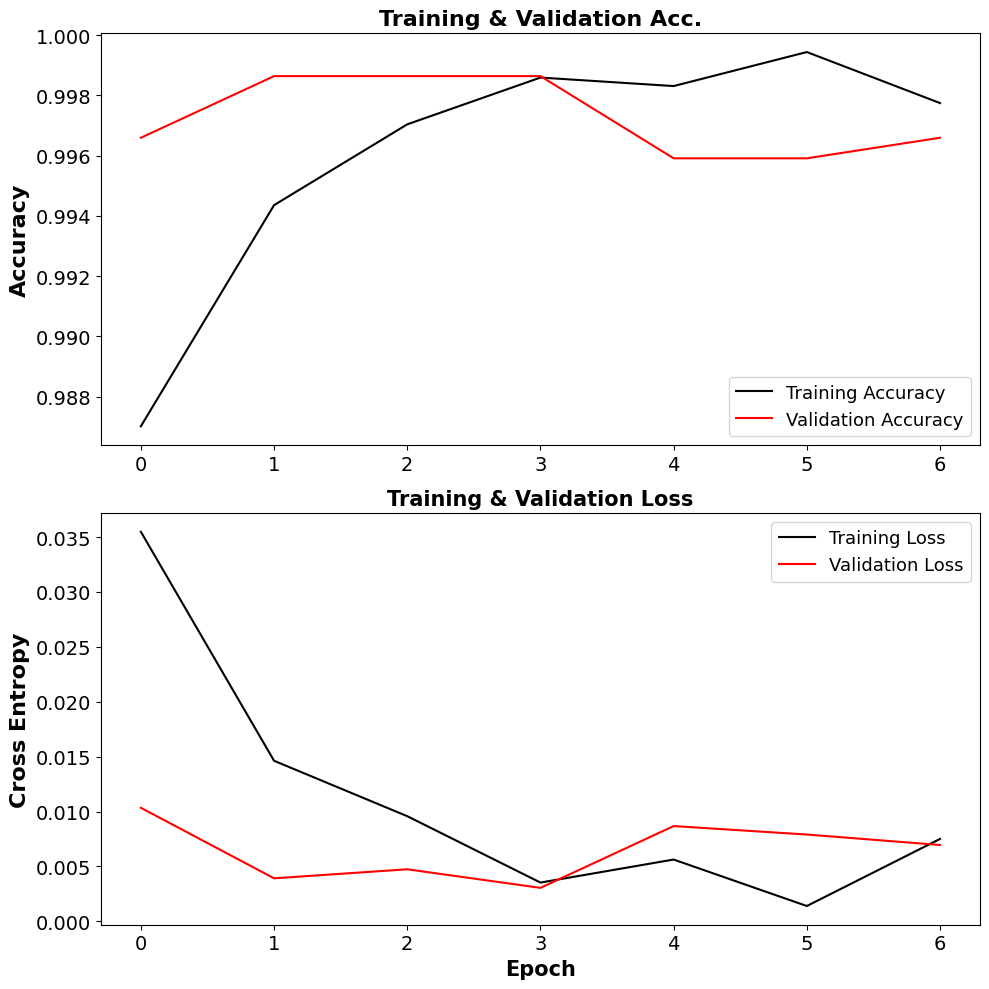

Saved: /content/lc25000-final-outputs/resnet50_training_curves.png


In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)

plt.plot(acc, label='Training Accuracy', color='black')
plt.plot(val_acc, label='Validation Accuracy', color='red')


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='lower right', fontsize=13)
plt.ylabel('Accuracy', fontsize=16, weight='bold')
plt.title('Training & Validation Acc.', fontsize=16, weight='bold')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss', color='black')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='upper right', fontsize=13)
plt.ylabel('Cross Entropy', fontsize=16, weight='bold')
plt.title('Training & Validation Loss', fontsize=15, weight='bold')
plt.xlabel('Epoch', fontsize=15, weight='bold')
plt.tight_layout()
TRAINING_CURVES_PATH = OUTPUT_DIR / 'resnet50_training_curves.png'
plt.savefig(TRAINING_CURVES_PATH, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', TRAINING_CURVES_PATH)


## 9. Untouched test-set evaluation

The best validation-selected checkpoint is evaluated once on the group-aware test
partition. A fixed threshold of 0.5 converts adenocarcinoma probabilities to labels.


In [30]:
# Load the checkpoint selected only by validation loss.
best_model = keras.models.load_model(BEST_MODEL_PATH)
assert test_resnet.shuffle is False

test_resnet.reset()
test_metrics = best_model.evaluate(
    test_dataset, steps=len(test_resnet), return_dict=True, verbose=1
)

test_resnet.reset()
test_probabilities = best_model.predict(test_resnet, verbose=1).ravel()
y_true = np.asarray(test_resnet.classes, dtype=int)
y_pred = (test_probabilities >= 0.5).astype(int)

expected_test_samples = len(test_df)
assert len(y_true) == expected_test_samples == 1451
assert test_probabilities.shape == (expected_test_samples,)
assert np.isfinite(test_probabilities).all()
assert ((test_probabilities >= 0.0) & (test_probabilities <= 1.0)).all()

target_names = ['benign', 'adenocarcinoma']
report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)
print(classification_report(
    y_true, y_pred, target_names=target_names, digits=4, zero_division=0
))
print('Test metrics:', test_metrics)

46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 1.0000 - loss: 4.8816e-04 - precision: 1.0000 - recall: 1.0000 - roc_auc: 1.0000
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step
                precision    recall  f1-score   support

        benign     1.0000    1.0000    1.0000       697
adenocarcinoma     1.0000    1.0000    1.0000       754

      accuracy                         1.0000      1451
     macro avg     1.0000    1.0000    1.0000      1451
  weighted avg     1.0000    1.0000    1.0000      1451

Test metrics: {'accuracy': 1.0, 'loss': 0.0004881550557911396, 'precision': 1.0, 'recall': 1.0, 'roc_auc': 1.0}


In [31]:
def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, weight='bold', fontsize=16)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=14)
    plt.yticks(tick_marks, classes, fontsize=14)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", fontsize=12, weight='bold',
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label', fontsize=16, weight='bold')
    plt.xlabel('Predicted label', fontsize=16, weight='bold')

Normalized confusion matrix


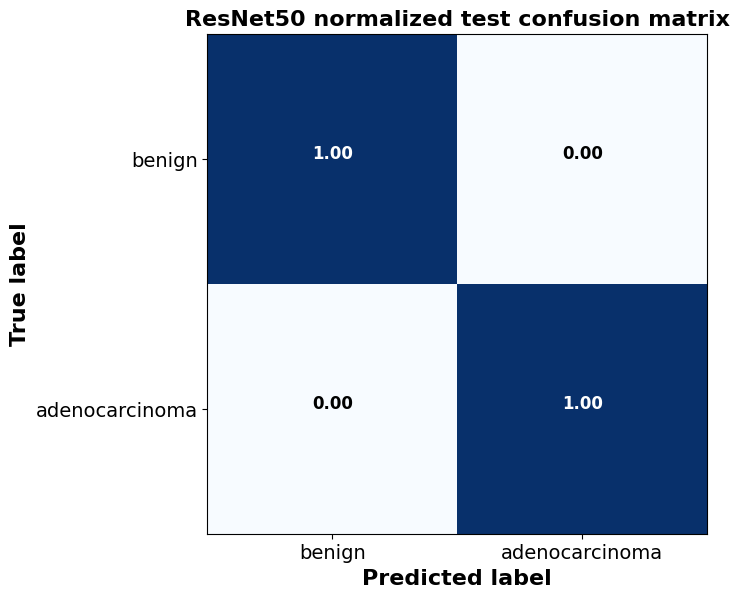

,benign,adenocarcinoma
benign,697,0
adenocarcinoma,0,754


In [32]:
cnf_matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
assert cnf_matrix.shape == (2, 2)
assert cnf_matrix.sum() == len(y_true) == 1451

CONFUSION_MATRIX_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix.csv'
CONFUSION_MATRIX_NORMALIZED_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix_normalized.csv'
CONFUSION_MATRIX_PLOT_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix.png'

cm_frame = pd.DataFrame(cnf_matrix, index=target_names, columns=target_names)
cm_frame.to_csv(CONFUSION_MATRIX_PATH)
cm_normalized = cnf_matrix / cnf_matrix.sum(axis=1, keepdims=True)
pd.DataFrame(cm_normalized, index=target_names, columns=target_names).to_csv(
    CONFUSION_MATRIX_NORMALIZED_PATH
)

plt.figure(figsize=(7, 7))
plot_confusion_matrix(
    cnf_matrix,
    classes=target_names,
    normalize=True,
    title='ResNet50 normalized test confusion matrix',
)
plt.savefig(CONFUSION_MATRIX_PLOT_PATH, dpi=160, bbox_inches='tight')
plt.show()
display(cm_frame)

In [33]:
METRICS_PATH = OUTPUT_DIR / 'resnet50_test_metrics.json'
REPORT_PATH = OUTPUT_DIR / 'resnet50_classification_report.json'
PREDICTIONS_PATH = OUTPUT_DIR / 'resnet50_test_predictions.csv'

metrics_evidence = {key: float(value) for key, value in test_metrics.items()}
metrics_evidence.update({
    'decision_threshold': 0.5,
    'test_samples': int(len(y_true)),
    'test_groups': int(test_df['group_id'].nunique()),
    'misclassified_images': int(np.sum(y_true != y_pred)),
    'groups_with_any_error': int(
        test_df.loc[y_true != y_pred, 'group_id'].nunique()
    ),
    'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
    'best_validation_loss': float(np.min(history.history['val_loss'])),
})
METRICS_PATH.write_text(json.dumps(metrics_evidence, indent=2), encoding='utf-8')
REPORT_PATH.write_text(json.dumps(report, indent=2), encoding='utf-8')
print('Evidence metrics:', metrics_evidence)

prediction_evidence = test_df[[
    'relative_path', 'class_name', 'label', 'group_id', 'local_cluster_label'
]].copy()
prediction_evidence['adenocarcinoma_probability'] = test_probabilities
prediction_evidence['predicted_label'] = y_pred
prediction_evidence['predicted_class'] = np.where(
    y_pred == 1, 'adenocarcinoma', 'benign'
)
prediction_evidence.to_csv(PREDICTIONS_PATH, index=False)

for artifact_path in [METRICS_PATH, REPORT_PATH, PREDICTIONS_PATH,
                      CONFUSION_MATRIX_PATH, CONFUSION_MATRIX_NORMALIZED_PATH,
                      CONFUSION_MATRIX_PLOT_PATH, TRAINING_CURVES_PATH]:
    assert artifact_path.is_file(), artifact_path
    print('Saved:', artifact_path)

Evidence metrics: {'accuracy': 1.0, 'loss': 0.0004881550557911396, 'precision': 1.0, 'recall': 1.0, 'roc_auc': 1.0, 'decision_threshold': 0.5, 'test_samples': 1451, 'test_groups': 77, 'misclassified_images': 0, 'groups_with_any_error': 0, 'best_epoch': 4, 'best_validation_loss': 0.003047516103833914}
Saved: /content/lc25000-final-outputs/resnet50_test_metrics.json
Saved: /content/lc25000-final-outputs/resnet50_classification_report.json
Saved: /content/lc25000-final-outputs/resnet50_test_predictions.csv
Saved: /content/lc25000-final-outputs/resnet50_confusion_matrix.csv
Saved: /content/lc25000-final-outputs/resnet50_confusion_matrix_normalized.csv
Saved: /content/lc25000-final-outputs/resnet50_confusion_matrix.png
Saved: /content/lc25000-final-outputs/resnet50_training_curves.png


## 10. Fair model comparison

Both approaches are compared on the exact same group-aware test rows. Logistic
regression is a deliberately simple color baseline; ResNet50 additionally observes
spatial texture and morphology. Neither result is evidence of clinical validity.


In [36]:
comparison = pd.DataFrame([
    {
        "model": "RGB histogram + logistic regression",
        "test_accuracy": float(histogram_accuracy),
        "macro_precision": float(histogram_report["macro avg"]["precision"]),
        "macro_recall": float(histogram_report["macro avg"]["recall"]),
        "macro_f1": float(histogram_report["macro avg"]["f1-score"]),
        "learned_parameters": int(histogram_baseline[-1].coef_.size + 1),
    },
    {
        "model": "Frozen ImageNet ResNet50",
        "test_accuracy": float(test_metrics["accuracy"]),
        "macro_precision": float(report["macro avg"]["precision"]),
        "macro_recall": float(report["macro avg"]["recall"]),
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "learned_parameters": int(trainable_parameters),
    },
])
comparison["accuracy_difference_from_baseline"] = (
    comparison["test_accuracy"] - float(histogram_accuracy)
)
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
comparison


,model,test_accuracy,macro_precision,macro_recall,macro_f1,learned_parameters,accuracy_difference_from_baseline
0,RGB histogram + logistic regression,0.911785,0.91836,0.914469,0.911692,97,0.000000
1,Frozen ImageNet ResNet50,1.000000,1.00000,1.000000,1.000000,270593,0.088215


## 11. Artifact preservation and reproducible inference

The best Keras checkpoint is hashed, described in a manifest, and kept outside
ordinary Git history. Compact metrics, predictions, manifests, and plots are
archived separately. The final cell reloads the selected checkpoint and predicts
one deterministic test example without retraining.


In [37]:
import hashlib
import zipfile

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

model_sha256 = sha256_file(BEST_MODEL_PATH)
MODEL_MANIFEST_PATH = OUTPUT_DIR / "resnet50_model_manifest.json"
model_manifest = {
    "schema_version": 1,
    "model_id": "resnet50-binary-colon-group-aware-final",
    "artifact": BEST_MODEL_PATH.name,
    "format": "keras_v3",
    "sha256": model_sha256,
    "size_bytes": BEST_MODEL_PATH.stat().st_size,
    "tensorflow_version": tf.__version__,
    "keras_version": keras.__version__,
    "input_shape": [IMG_SIZE, IMG_SIZE, 3],
    "preprocessing": "explicit Caffe-style RGB-to-BGR and ImageNet mean subtraction",
    "class_mapping": {"benign": 0, "adenocarcinoma": 1},
    "output": "adenocarcinoma_probability",
    "decision_threshold": 0.5,
    "selection_metric": "validation loss",
    "split_manifest": GROUP_SPLIT_MANIFEST_PATH.name,
}
MODEL_MANIFEST_PATH.write_text(
    json.dumps(model_manifest, indent=2), encoding="utf-8"
)

EVIDENCE_ARCHIVE_PATH = Path("/content/lc25000-final-evidence.zip")
with zipfile.ZipFile(EVIDENCE_ARCHIVE_PATH, "w", zipfile.ZIP_DEFLATED) as archive:
    for artifact_path in sorted(OUTPUT_DIR.iterdir()):
        if artifact_path.is_file() and artifact_path != BEST_MODEL_PATH:
            archive.write(artifact_path, arcname=artifact_path.name)

print("Model:", BEST_MODEL_PATH)
print("SHA-256:", model_sha256)
print("Evidence archive:", EVIDENCE_ARCHIVE_PATH)


Model: /content/lc25000-final-outputs/resnet50_binary_best.keras
SHA-256: e48e3afcf2521e731fa68ed4f8585cb3c19d864f5d563aae74246cd88a4d86d1
Evidence archive: /content/lc25000-final-evidence.zip


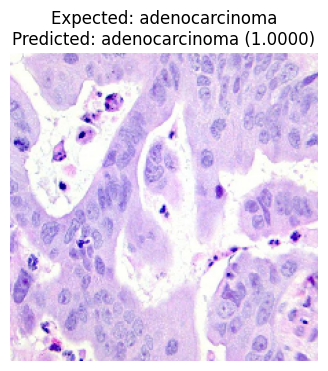

{'relative_path': 'colon_aca/colonca100.jpeg', 'expected_class': 'adenocarcinoma', 'predicted_class': 'adenocarcinoma', 'adenocarcinoma_probability': 1.0}


In [38]:
inference_model = keras.models.load_model(BEST_MODEL_PATH)
sample = test_df.sort_values("relative_path").iloc[0]
sample_image = keras.utils.load_img(
    sample["filepath"],
    color_mode="rgb",
    target_size=(IMG_SIZE, IMG_SIZE),
    interpolation="nearest",
)
sample_array = np.asarray(sample_image, dtype=np.float32)
sample_batch = preprocess_resnet50(sample_array.copy())[None, ...]
sample_probability = float(inference_model.predict(sample_batch, verbose=0)[0, 0])
sample_prediction = "adenocarcinoma" if sample_probability >= 0.5 else "benign"

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.axis("off")
plt.title(
    f"Expected: {sample['class_name']}\n"
    f"Predicted: {sample_prediction} ({sample_probability:.4f})"
)
plt.show()

assert sample_prediction in {"benign", "adenocarcinoma"}
print({
    "relative_path": sample["relative_path"],
    "expected_class": sample["class_name"],
    "predicted_class": sample_prediction,
    "adenocarcinoma_probability": sample_probability,
})


## 12. Conclusions to complete after execution

After the clean run, report the observed values rather than copying historical
numbers. Discuss:

- the logistic baseline's performance and what it reveals about color separability;
- the additional performance obtained by ResNet50;
- the random-split similarity audit and why group-aware evaluation is preferred;
- the remaining absence of patient-level and external-cohort validation;
- why the selected model is suitable only for the educational demonstration.
